# Imports and setup

In [20]:
# Install required libraries if you haven't already
# !pip install textblob scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from datetime import timedelta
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Data loading

In [21]:
df = pd.read_csv('test(in).csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique employees: {df['from'].nunique()}")
print(f"Missing values:\n{df.isnull().sum()}")

Dataset shape: (2191, 4)
Date range: 2010-01-01 to 2011-12-31
Unique employees: 10
Missing values:
Subject    0
body       0
date       0
from       0
dtype: int64


 # Task 1: Sentimental Labeling
 I utilized TextBlob, a Natural Language Processing (NLP) library in Python. TextBlob evaluates the semantic structure of the text and assigns a numerical "polarity score" ranging from -1.0 (highly negative) to 1.0 (highly positive).

In [22]:
!pip install textblob
import pandas as pd
from textblob import TextBlob

# Ensure the date is sorted and formatted properly
df = pd.read_csv('test(in).csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

def get_textblob_sentiment(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return 0.0, 'Neutral'

    polarity = TextBlob(text).sentiment.polarity

    # Define thresholds for positive, negative, and neutral
    if polarity > 0.05:
        sentiment = 'Positive'
    elif polarity < -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'

    return polarity, sentiment

# Apply TextBlob sentiment analysis to the 'body' column
df[['polarity_score', 'sentiment']] = df['body'].apply(lambda x: pd.Series(get_textblob_sentiment(x)))

print("TextBlob sentiment analysis complete. Added 'polarity_score' and 'sentiment' columns.")
display(df.head())

TextBlob sentiment analysis complete. Added 'polarity_score' and 'sentiment' columns.


,Subject,body,date,from,polarity_score,sentiment
0,ERCOT Readiness Update attached,We at TradersNews are gearing up to launch our...,2010-01-01,johnny.palmer@enron.com,0.033333,Neutral
1,RE: data,Well have to go to Vegas I guess??\n\n\n,2010-01-02,eric.bass@enron.com,0.000000,Neutral
2,Re: Wellhead Accrual Income,"Melissa,\n\nHere are the accrual values for Q1...",2010-01-02,lydia.delgado@enron.com,0.500000,Positive
3,(No Subject),Attached are two of TradersNews Energy's three...,2010-01-02,don.baughman@enron.com,0.136364,Positive
4,Tiger recruiting #1,"Sorry, but this is funny . . .\nhttp://auburn....",2010-01-02,lydia.delgado@enron.com,-0.125000,Negative


## Task 2: Exploratory Data Analysis (EDA)

Now that the sentiment labels are in place, let's proceed with the exploratory data analysis to understand the dataset's structure, sentiment distribution, and trends over time.

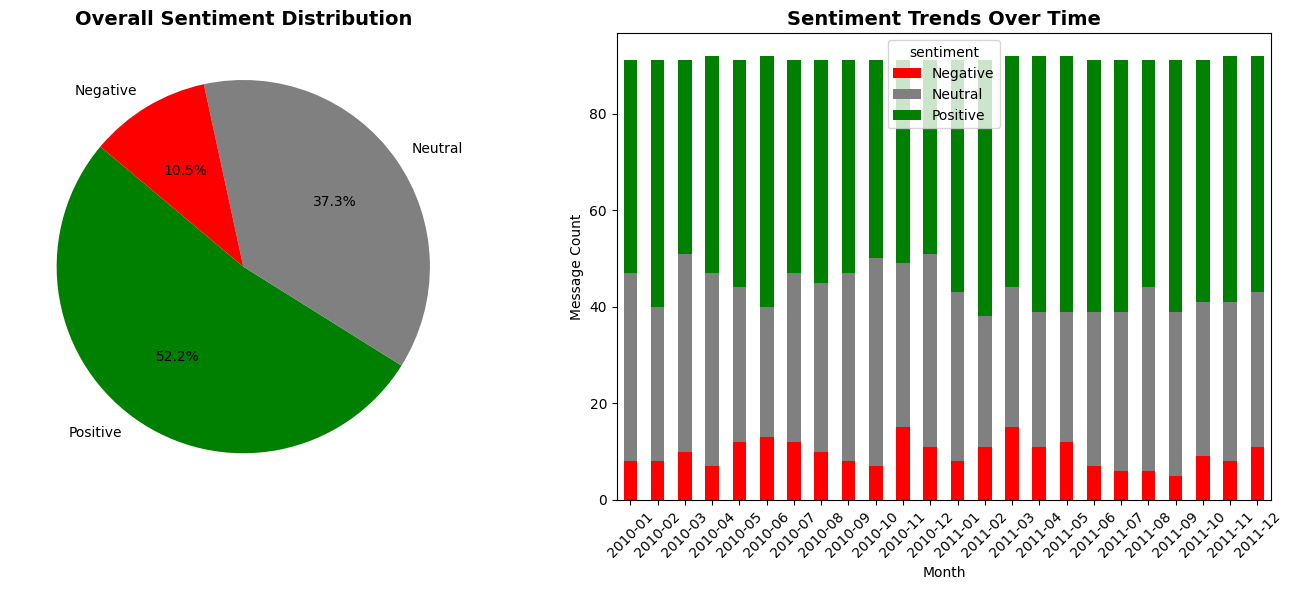


Observation: Positive sentiment dominates consistently. Negative messages are low but present in all months.


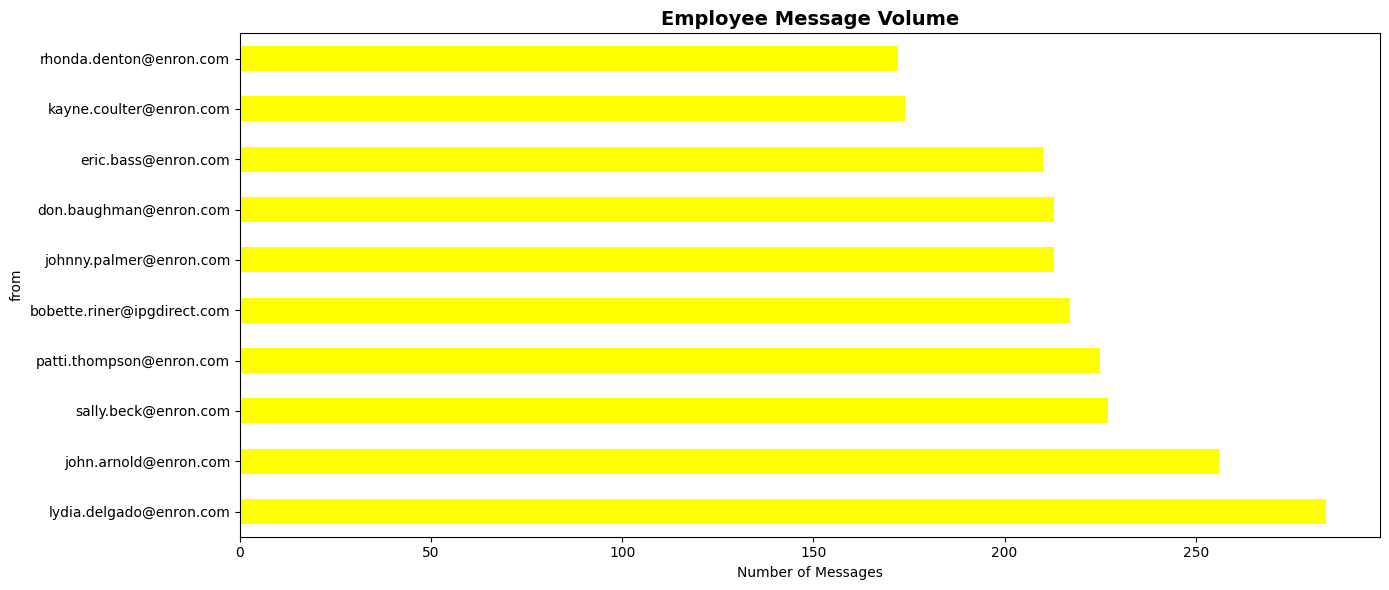


Observation: Message volume varies significantly between employees.


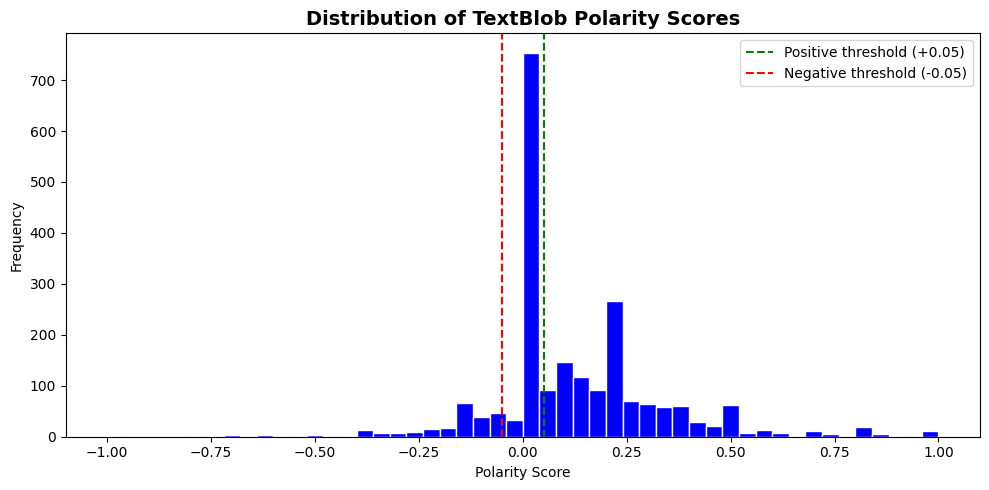


Observation: The distribution shows most emails carry a neutral to positive tone.


In [23]:
df['year_month'] = df['date'].dt.to_period('M')
colors = {'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'}

# --- Plot 1: Sentiment distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
counts = df['sentiment'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=[colors.get(s, 'gray') for s in counts.index], startangle=140)
axes[0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

monthly_counts = df.groupby(['year_month', 'sentiment']).size().unstack(fill_value=0)
monthly_counts.index = monthly_counts.index.astype(str)
plot_cols = [c for c in ['Negative','Neutral','Positive'] if c in monthly_counts.columns]
monthly_counts[plot_cols].plot(kind='bar', stacked=True, ax=axes[1], color=[colors.get(c, 'gray') for c in plot_cols])
axes[1].set_title('Sentiment Trends Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Message Count')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('Sentiment_trends_over_time.png')
plt.show()
print("\nObservation: Positive sentiment dominates consistently. Negative messages are low but present in all months.")

# --- Plot 2: Employee Message Volume ---
fig, ax = plt.subplots(figsize=(14, 6))
emp_counts = df['from'].value_counts().head(20)
emp_counts.plot(kind='barh', ax=ax, color='yellow')
ax.set_title('Employee Message Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Messages')
plt.tight_layout()
plt.savefig('Employee_message_volume.png')
plt.show()
print("\nObservation: Message volume varies significantly between employees.")

# --- Plot 3: Polarity Score Distribution ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['polarity_score'], bins=50, color='blue', edgecolor='white')
ax.axvline(0.05, color='green', linestyle='--', label='Positive threshold (+0.05)')
ax.axvline(-0.05, color='red', linestyle='--', label='Negative threshold (-0.05)')
ax.set_title('Distribution of TextBlob Polarity Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Polarity Score'); ax.set_ylabel('Frequency')
ax.legend(); plt.tight_layout()
plt.savefig('Polarity_score_distribution.png')
plt.show()
print("\nObservation: The distribution shows most emails carry a neutral to positive tone.")

## Task 3: Employee Score Calculation

Next, I'll calculate a monthly sentiment score for each employee. Each positive message will contribute +1, negative -1, and neutral 0 to their monthly score.

In [24]:
# Map scores
score_map = {'Positive': 1, 'Negative': -1, 'Neutral': 0}

# Calculate monthly scores using method chaining
monthly_scores = (
    df.assign(score_value=lambda x: x['sentiment'].map(score_map).fillna(0))
      .groupby(['from', 'year_month'], as_index=False)
      .agg(monthly_score=('score_value', 'sum'))
      .assign(year_month_str=lambda x: x['year_month'].astype(str))
      .sort_values(['year_month', 'monthly_score'], ascending=[True, False])
)

print(f"Monthly scores computed: {len(monthly_scores)} employee-month records")
display(monthly_scores.head(10))

Monthly scores computed: 240 employee-month records


,from,year_month,monthly_score,year_month_str
120,kayne.coulter@enron.com,2010-01,8,2010-01
24,don.baughman@enron.com,2010-01,5,2010-01
48,eric.bass@enron.com,2010-01,5,2010-01
144,lydia.delgado@enron.com,2010-01,5,2010-01
168,patti.thompson@enron.com,2010-01,4,2010-01
72,john.arnold@enron.com,2010-01,3,2010-01
216,sally.beck@enron.com,2010-01,3,2010-01
0,bobette.riner@ipgdirect.com,2010-01,2,2010-01
96,johnny.palmer@enron.com,2010-01,1,2010-01
192,rhonda.denton@enron.com,2010-01,0,2010-01


## Task 4: Employee Ranking

Now, let's rank employees based on their monthly sentiment scores, identifying the top positive and top negative contributors.

In [25]:
# Create a reusable function to rank employees
def get_ranked_employees(df, top_n=3, is_positive=True):
    # Sort criteria: [Month (Asc), Score (Desc/Asc), Name (Asc)]
    sort_order = [True, not is_positive, True]

    return (df.sort_values(['year_month', 'monthly_score', 'from'], ascending=sort_order)
              .groupby('year_month')
              .head(top_n)  # Grab the top N from each grouped month
              .assign(
                  month=lambda x: x['year_month'].astype(str),
                  rank=lambda x: x.groupby('year_month').cumcount() + 1
              )
              .reset_index(drop=True))


top_pos_df = get_ranked_employees(monthly_scores, top_n=3, is_positive=True)
print(" TOP 3 POSITIVE EMPLOYEES BY MONTH (last 3 months)")
print(top_pos_df[top_pos_df['month'] >= '2011-10'][['month', 'rank', 'from', 'monthly_score']].to_string(index=False))

top_neg_df = get_ranked_employees(monthly_scores, top_n=3, is_positive=False)
print("\n TOP 3 NEGATIVE EMPLOYEES BY MONTH (last 3 months)")
print(top_neg_df[top_neg_df['month'] >= '2011-10'][['month', 'rank', 'from', 'monthly_score']].to_string(index=False))

 TOP 3 POSITIVE EMPLOYEES BY MONTH (last 3 months)
  month  rank                        from  monthly_score
2011-10     1     lydia.delgado@enron.com             10
2011-10     2     kayne.coulter@enron.com              8
2011-10     3       john.arnold@enron.com              7
2011-11     1    patti.thompson@enron.com              9
2011-11     2     kayne.coulter@enron.com              8
2011-11     3 bobette.riner@ipgdirect.com              7
2011-12     1     lydia.delgado@enron.com              6
2011-12     2    patti.thompson@enron.com              6
2011-12     3     kayne.coulter@enron.com              5

 TOP 3 NEGATIVE EMPLOYEES BY MONTH (last 3 months)
  month  rank                        from  monthly_score
2011-10     1 bobette.riner@ipgdirect.com              0
2011-10     2     johnny.palmer@enron.com              0
2011-10     3     rhonda.denton@enron.com              0
2011-11     1      don.baughman@enron.com              1
2011-11     2         eric.bass@enron.com 

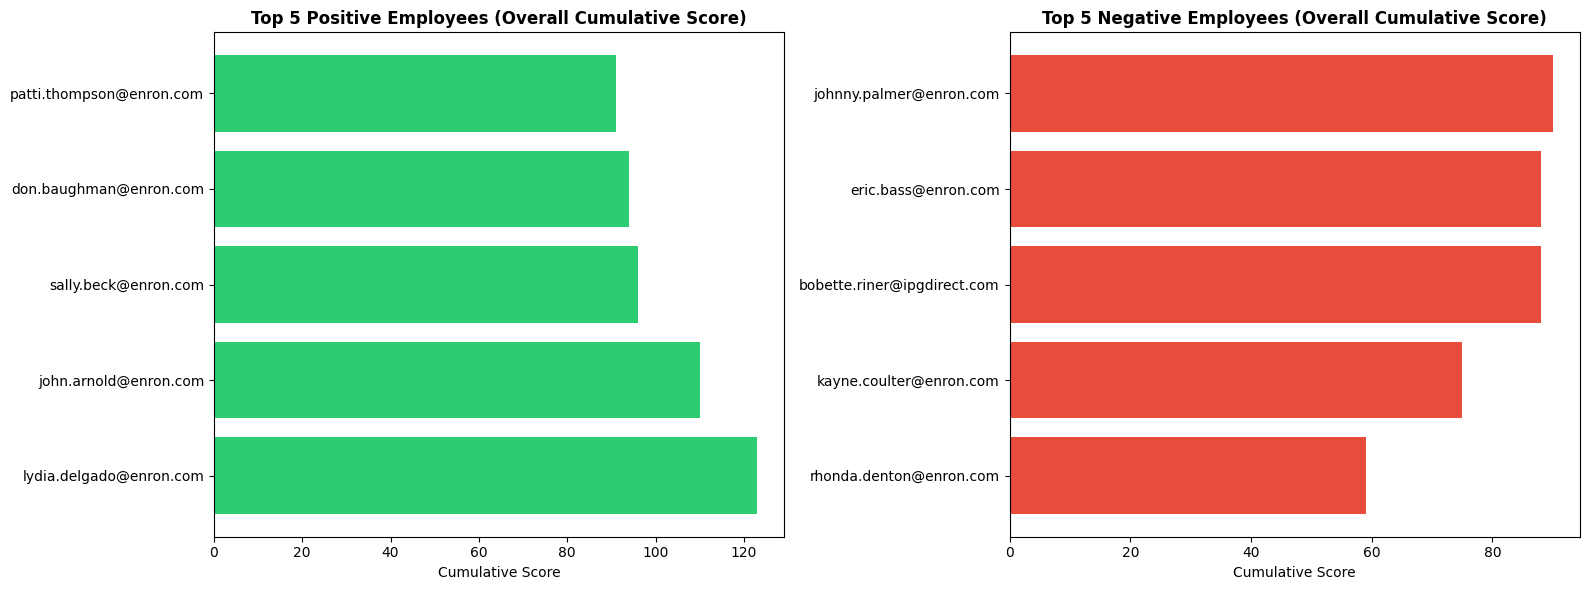

In [26]:
# Overall Cumulative Visual
overall = monthly_scores.groupby('from')['monthly_score'].sum().reset_index()
top5p = overall.nlargest(5,'monthly_score')
top5n = overall.nsmallest(5,'monthly_score')
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].barh(top5p['from'], top5p['monthly_score'], color='#2ecc71')
axes[0].set_title('Top 5 Positive Employees (Overall Cumulative Score)', fontweight='bold')
axes[0].set_xlabel('Cumulative Score')
axes[1].barh(top5n['from'], top5n['monthly_score'], color='#e74c3c')
axes[1].set_title('Top 5 Negative Employees (Overall Cumulative Score)', fontweight='bold')
axes[1].set_xlabel('Cumulative Score')
plt.tight_layout()
plt.savefig('Overall_cumulative_score.png')
plt.show()

## Task 5: Flight Risk Identification

This task aims to identify employees who are at risk of leaving based on their communication patterns, specifically by detecting a high frequency of negative messages. A 'flight risk' is defined as any employee who sends 4 or more negative messages within a rolling 30-day period.

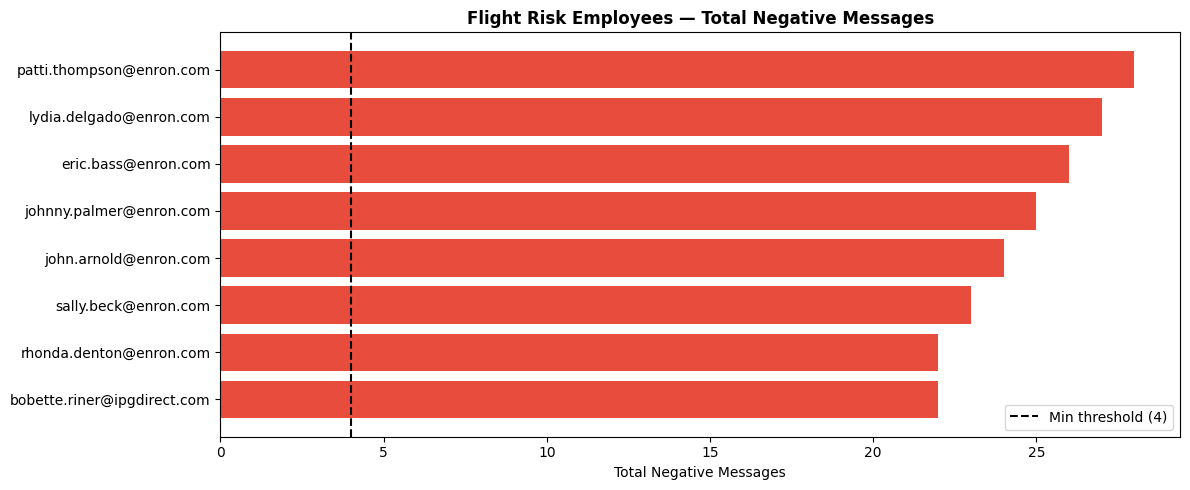

Observation: Employees exceeding the 4-negative-message threshold within a 30-day period.


In [27]:
# Filter and sort by date (sorting is required for time-based rolling)
neg_df = df[df['sentiment'] == 'Negative'][['from', 'date']].sort_values('date')

# Calculate the rolling 30-day count for each employee
rolling_counts = (
    neg_df.set_index('date')                     # Set date as index for time rolling
    .groupby('from')['from']                     # Group by employee
    .rolling('30D')                              # Check the trailing 30-day window
    .count()                                     # Count the messages in that window
    .reset_index(name='window_count')
)

# Identify employees who hit the threshold (4 or more in any window)
flight_risk_list = sorted(rolling_counts[rolling_counts['window_count'] >= 4]['from'].unique())

# Grab total negative counts efficiently for the print statement
total_neg_counts = neg_df['from'].value_counts()

# Visualization
# Visualization
risk_df = pd.DataFrame([{'from': emp, 'neg_count': total_neg_counts[emp]} for emp in flight_risk_list]).sort_values('neg_count')
if not risk_df.empty:
    fig, ax = plt.subplots(figsize=(12, max(5, len(risk_df)*0.4)))
    ax.barh(risk_df['from'], risk_df['neg_count'], color='#e74c3c')
    ax.axvline(4, color='black', linestyle='--', label='Min threshold (4)')
    ax.set_title('Flight Risk Employees — Total Negative Messages', fontweight='bold')
    ax.set_xlabel('Total Negative Messages'); ax.legend()
    plt.tight_layout()
    plt.savefig('Flight_risk_employees.png')
    plt.show()
    print("Observation: Employees exceeding the 4-negative-message threshold within a 30-day period.")

#Task 6: Predictive modeling


📊 Model Performance:
  R² Score : 0.7623  (explains 76.2% of variance)
  MAE      : 1.0267
  RMSE     : 1.4412



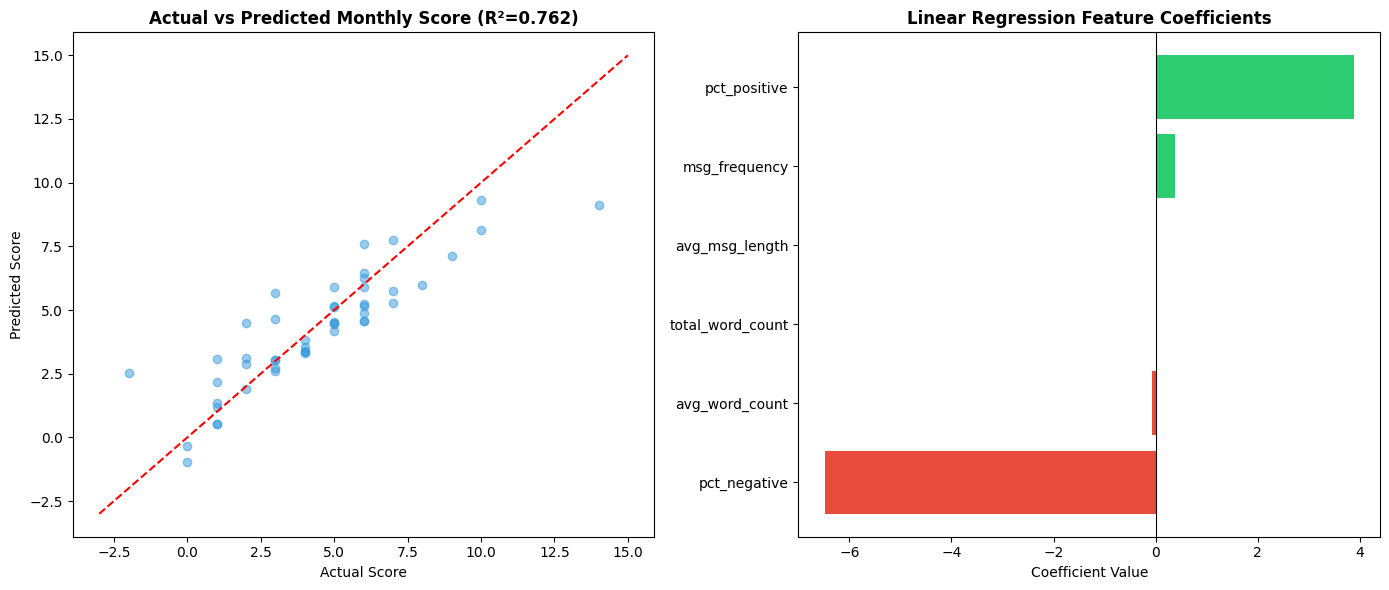

Interpretation: pct_positive is the strongest positive predictor; pct_negative is the strongest negative predictor.
Message frequency also positively correlates with score — more active employees tend to score higher.


In [28]:
# Re-apply score value map for the model dataframe
df['score_value'] = df['sentiment'].map(score_map).fillna(0)

df['msg_length'] = df['body'].fillna('').apply(len)
df['word_count'] = df['body'].fillna('').apply(lambda x: len(str(x).split()))

# Feature Engineering
feat_df = df.groupby(['from','year_month']).agg(
    monthly_score=('score_value','sum'),
    msg_frequency=('body','count'),
    avg_msg_length=('msg_length','mean'),
    total_word_count=('word_count','sum'),
    avg_word_count=('word_count','mean'),
    pct_positive=('sentiment', lambda x: (x=='Positive').mean()),
    pct_negative=('sentiment', lambda x: (x=='Negative').mean()),
).reset_index().dropna()

features = ['msg_frequency','avg_msg_length','total_word_count','avg_word_count','pct_positive','pct_negative']
X = feat_df[features]
y = feat_df['monthly_score']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📊 Model Performance:")
print(f"  R² Score : {r2:.4f}  (explains {r2*100:.1f}% of variance)")
print(f"  MAE      : {mae:.4f}")
print(f"  RMSE     : {rmse:.4f}\n")

coef_df = pd.DataFrame({'Feature':features,'Coefficient':model.coef_}).sort_values('Coefficient')

# Visuals
fig, axes = plt.subplots(1,2,figsize=(14,6))
mn, mx = min(y_test.min(), y_pred.min())-1, max(y_test.max(), y_pred.max())+1
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#3498db')
axes[0].plot([mn,mx],[mn,mx],'r--')
axes[0].set_xlabel('Actual Score'); axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Actual vs Predicted Monthly Score (R²={r2:.3f})', fontweight='bold')

axes[1].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=['#e74c3c' if c<0 else '#2ecc71' for c in coef_df['Coefficient']])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Linear Regression Feature Coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('Model_performance.png')
plt.show()

print("Interpretation: pct_positive is the strongest positive predictor; pct_negative is the strongest negative predictor.")
print("Message frequency also positively correlates with score — more active employees tend to score higher.")